<a href="https://colab.research.google.com/github/iras-mpark/MLA1020/blob/main/week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from dataclasses import dataclass
from typing import Any


@dataclass(frozen=True)
class Step:
    action: Any
    prob: float  # New: the probability that we ended up here
    reward: float
    state: Any
class MDP:
    def start_state(self) -> Any:
        raise NotImplementedError

    def successors(self, state: Any) -> list[Step]:
        raise NotImplementedError

    def is_end(self, state: Any) -> bool:
        raise NotImplementedError
    def discount(self) -> float:
        raise NotImplementedError
class FlakyTramMDP(MDP):
    def __init__(self, num_locs: int, failure_prob: float):
        self.num_locs = num_locs
        self.failure_prob = failure_prob
    def start_state(self) -> Any:
        return 1

    def successors(self, state: Any) -> list[Step]:
        successors = []
        # Walk
        if state + 1 <= self.num_locs:
            successors.append(Step(action="walk", prob=1, reward=-1, state=state + 1))
        # Tram
        if 2 * state <= self.num_locs:
            # Success: move to desired state
            successors.append(Step(action="tram", prob=1 - self.failure_prob, reward=-2, state=2 * state))
            # Failure: stay in the same state
            successors.append(Step(action="tram", prob=self.failure_prob, reward=-2, state=state))
        return successors
    def is_end(self, state: Any) -> bool:
        return state == self.num_locs
    def discount(self) -> float:
        # No discounting for now
        return 1


In [ ]:
mdp = FlakyTramMDP(num_locs=10, failure_prob=0.4)
state = mdp.start_state()
successors = mdp.successors(state)
is_end = mdp.is_end(successors[0].state)

In [ ]:
print(f"Is end state: {is_end}")
print(f"Current state: {state}")
print(f"Successors: {successors}")

Is end state: False
Current state: 1
Successors: [Step(action='walk', prob=1, reward=-1, state=2), Step(action='tram', prob=0.6, reward=-2, state=2), Step(action='tram', prob=0.4, reward=-2, state=1)]


### Dice Example

In [ ]:
class DiceGameMDP(MDP):
    def start_state(self) -> Any:
        return "in"

    def successors(self, state: Any) -> list[Step]:
        return [
            Step(action="quit", prob=1, reward=10, state="end"),
            Step(action="stay", prob=1/3, reward=4, state="end"),
            Step(action="stay", prob=2/3, reward=4, state="in"),
        ]

    def is_end(self, state: Any) -> bool:
        return state == "end"

    def discount(self) -> float:
        return 1

In [ ]:
mdp = DiceGameMDP()
state = mdp.start_state()
successors = mdp.successors(state)
is_end = mdp.is_end(successors[0].state)

In [ ]:
print(f"Is end state: {is_end}")
print(f"Current state: {state}")
print(f"Successors: {successors}")

Is end state: True
Current state: in
Successors: [Step(action='quit', prob=1, reward=10, state='end'), Step(action='stay', prob=0.3333333333333333, reward=4, state='end'), Step(action='stay', prob=0.6666666666666666, reward=4, state='in')]


### Policy

In [ ]:
def always_stay_policy(state: int) -> str:
    return "stay"
def always_quit_policy(state: int) -> str:
    return "quit"
def always_walk_policy(state: int) -> str:
    return "walk"
def tram_if_possible_policy(mdp: MDP, state: int) -> str:
    """Need the MDP to know the number of locations to make sure we can take the tram."""
    if state * 2 <= mdp.num_locs:
        return "tram"
    else:
        return "walk"

In [ ]:
mdp = FlakyTramMDP(num_locs=10, failure_prob=0.4)
action = always_walk_policy(state=3)
print(f"Action: {action}")

action = tram_if_possible_policy(mdp, state=3)
print(f"Action: {action}")

action = tram_if_possible_policy(mdp, state=6)
print(f"Action: {action}")

Action: walk
Action: tram
Action: walk


###Rollout

In [ ]:
from typing import Callable
import numpy as np

Policy = Callable[[Any], Any]

@dataclass
class Rollout:
    """Represents a rollout of an MDP (sequence of actions that produces a utility)."""
    steps: list[Step]
    discount: float
    utility: float  # Discounted sum of rewards
    def __init__(self, steps: list[Step], discount: float):
        self.steps = steps
        self.discount = discount
        self.utility = compute_utility(steps, discount)

def compute_utility(steps: list[Step], discount: float) -> float:
    """Computes the utility (discounted sum of rewards) of a rollout."""
    rewards = [step.reward * discount ** i for i, step in enumerate(steps)]
    utility = sum(rewards)
    return utility

def generate_rollout(mdp: MDP, policy: Policy) -> Rollout:
    """Run the `policy` in the `mdp` and return the rollout."""
    steps = []
    state = mdp.start_state()
    while not mdp.is_end(state):
        # Policy: choose an action
        action = policy(state)
        # MDP: choose a successor according to that action
        successors = [successor for successor in mdp.successors(state) if successor.action == action]
        probs = [successor.prob for successor in successors]
        choice = np.random.choice(len(successors), p=probs)
        step = successors[choice]
        steps.append(step)
        # Advance to the next state
        state = step.state
    return Rollout(steps=steps, discount=mdp.discount())

In [ ]:
np.random.seed(1)
rollout = generate_rollout(mdp, always_walk_policy)

In [ ]:
print("Rollout Details:")
for i, step in enumerate(rollout.steps):
    print(f"  Step {i+1}: {step}")
print(f"Discount: {rollout.discount}")
print(f"Utility: {rollout.utility}")

Rollout Details:
  Step 1: Step(action='walk', prob=1, reward=-1, state=2)
  Step 2: Step(action='walk', prob=1, reward=-1, state=3)
  Step 3: Step(action='walk', prob=1, reward=-1, state=4)
  Step 4: Step(action='walk', prob=1, reward=-1, state=5)
  Step 5: Step(action='walk', prob=1, reward=-1, state=6)
  Step 6: Step(action='walk', prob=1, reward=-1, state=7)
  Step 7: Step(action='walk', prob=1, reward=-1, state=8)
  Step 8: Step(action='walk', prob=1, reward=-1, state=9)
  Step 9: Step(action='walk', prob=1, reward=-1, state=10)
Discount: 1
Utility: -9


In [ ]:
utility_1 = compute_utility(rollout.steps, discount=1)
print(r"Utility with \gamma = 1:", utility_1)
utility_0 = compute_utility(rollout.steps, discount=0)
print(r"Utility with \gamma = 0:", utility_0)
utility_0_5 = compute_utility(rollout.steps, discount=0.5)
print(r"Utility with \gamma = 0.5:", utility_0_5)

Utility with \gamma = 1: -9
Utility with \gamma = 0: -1
Utility with \gamma = 0.5: -1.99609375


In [ ]:
from functools import partial

rollout = generate_rollout(mdp, partial(tram_if_possible_policy, mdp))
print("Rollout Details:")
for i, step in enumerate(rollout.steps):
    print(f"  Step {i+1}: {step}")
print(f"Discount: {rollout.discount}")
print(f"Utility: {rollout.utility}")

rollout = generate_rollout(mdp, partial(tram_if_possible_policy, mdp))
print("Rollout Details:")
for i, step in enumerate(rollout.steps):
    print(f"  Step {i+1}: {step}")
print(f"Discount: {rollout.discount}")
print(f"Utility: {rollout.utility}")

rollout = generate_rollout(mdp, partial(tram_if_possible_policy, mdp))
print("Rollout Details:")
for i, step in enumerate(rollout.steps):
    print(f"  Step {i+1}: {step}")
print(f"Discount: {rollout.discount}")
print(f"Utility: {rollout.utility}")

Rollout Details:
  Step 1: Step(action='tram', prob=0.6, reward=-2, state=2)
  Step 2: Step(action='tram', prob=0.6, reward=-2, state=4)
  Step 3: Step(action='tram', prob=0.4, reward=-2, state=4)
  Step 4: Step(action='tram', prob=0.6, reward=-2, state=8)
  Step 5: Step(action='walk', prob=1, reward=-1, state=9)
  Step 6: Step(action='walk', prob=1, reward=-1, state=10)
Discount: 1
Utility: -10
Rollout Details:
  Step 1: Step(action='tram', prob=0.4, reward=-2, state=1)
  Step 2: Step(action='tram', prob=0.6, reward=-2, state=2)
  Step 3: Step(action='tram', prob=0.6, reward=-2, state=4)
  Step 4: Step(action='tram', prob=0.6, reward=-2, state=8)
  Step 5: Step(action='walk', prob=1, reward=-1, state=9)
  Step 6: Step(action='walk', prob=1, reward=-1, state=10)
Discount: 1
Utility: -10
Rollout Details:
  Step 1: Step(action='tram', prob=0.4, reward=-2, state=1)
  Step 2: Step(action='tram', prob=0.6, reward=-2, state=2)
  Step 3: Step(action='tram', prob=0.4, reward=-2, state=2)
  Ste

### Monte Carlo Method

In [ ]:
def monte_carlo_policy_evaluation(mdp: MDP, policy: Policy, num_rollouts: int) -> float:
    """Evaluate the policy and return the expected utility."""
    utilities = [generate_rollout(mdp, policy).utility for _ in range(num_rollouts)]
    average_utility = np.mean(utilities)
    return average_utility

In [ ]:
walk_value = monte_carlo_policy_evaluation(mdp, always_walk_policy, num_rollouts=1)
tram_value = monte_carlo_policy_evaluation(mdp, partial(tram_if_possible_policy, mdp), num_rollouts=20)

In [ ]:
print(r"always_walk_policy:", walk_value)
print(r"tram_if_possible_policy:", tram_value)

always_walk_policy: -9.0
tram_if_possible_policy: -12.1


### Q-value

In [ ]:
from collections import defaultdict


def get_states(mdp: MDP) -> list[Any]:
    """Get all the states by traversing all successors starting from the start state."""
    states = set()
    def recurse(state: Any):
        if state in states:
            return
        states.add(state)
        for step in mdp.successors(state):
            recurse(step.state)
    recurse(mdp.start_state())
    return list(states)

def get_initial_values(mdp: MDP) -> dict[Any, float]:
    """
    Return the values obtained by just terminating.
    This is used to initialize policy evaluation and value iteration.
    Returns:
    - values: dict[Any, float]: state -> value of that state
    """
    # Get all the states in the MDP (needed for iterative algorithms)
    states = get_states(mdp)
    # Value is 0 for end states and -inf for other states
    values = {state: 0 if mdp.is_end(state) else -100 for state in states}
    return values

def get_action_successors(mdp: MDP, state: Any) -> dict[str, list[Step]]:
    """
    Get the successors for each action from a state.
    Returns:
    - action_to_successors: dict[str, list[Step]]: action -> list of successors for that action
    """
    # Get a flat list of successors for all actions
    successors = mdp.successors(state)
    # Group successors by action
    action_to_successors = defaultdict(list)
    for step in successors:
        action_to_successors[step.action].append(step)
    return action_to_successors

def compute_q_value(successors: list[Step], discount: float, values: dict[Any, float]) -> float:
    """Compute the Q-value for a list of `successors` (possible transitions) given the `values`."""
    weighted_utilities = []
    for step in successors:
        utility = step.reward + discount * values[step.state]
        weighted_utilities.append(step.prob * utility)
    value = sum(weighted_utilities)
    return value

In [ ]:
mdp = FlakyTramMDP(num_locs=10, failure_prob=0.4)
values = get_initial_values(mdp)

old_values = values.copy()
# Choose a state (arbitrarily)
state = 9
# Take the policy that takes the tram
policy = partial(tram_if_possible_policy, mdp)
# Get the action the policy would take in that state
action = policy(state)
# Get the successors of that action
successors = get_action_successors(mdp, state)[action]
# Key step: compute the value corresponding to taking that action and then terminating.
value = compute_q_value(successors, mdp.discount(), values)

values[state] = value
new_values = values

In [ ]:
print(f"Initial values: {old_values}")

print(f"Action: {action}")
print(f"Q-value: {value}")
print(f"Successors for this action: {successors}")

print(f"Initial values: {new_values}")

Initial values: {1: -100, 2: -100, 3: -100, 4: -100, 5: -100, 6: -100, 7: -100, 8: -100, 9: -100, 10: 0}
Action: walk
Q-value: -1
Successors for this action: [Step(action='walk', prob=1, reward=-1, state=10)]
Initial values: {1: -100, 2: -100, 3: -100, 4: -100, 5: -100, 6: -100, 7: -100, 8: -100, 9: -1, 10: 0}


In [ ]:
old_values = values.copy()
# Choose a state (arbitrarily)
state = 8
# Take the policy that takes the tram
policy = partial(tram_if_possible_policy, mdp)
# Get the action the policy would take in that state
action = policy(state)
# Get the successors of that action
successors = get_action_successors(mdp, state)[action]
# Key step: compute the value corresponding to taking that action and then terminating.
value = compute_q_value(successors, mdp.discount(), values)

values[state] = value
new_values = values

print(f"Initial values: {old_values}")

print(f"Action: {action}")
print(f"Q-value: {value}")
print(f"Successors for this action: {successors}")

print(f"Initial values: {new_values}")

Initial values: {1: -100, 2: -100, 3: -100, 4: -100, 5: -100, 6: -100, 7: -100, 8: -100, 9: -1, 10: 0}
Action: walk
Q-value: -2
Successors for this action: [Step(action='walk', prob=1, reward=-1, state=9)]
Initial values: {1: -100, 2: -100, 3: -100, 4: -100, 5: -100, 6: -100, 7: -100, 8: -2, 9: -1, 10: 0}


... 뒤에서부터 state 반복

In [ ]:
def compute_distance(values: dict[Any, float], new_values: dict[Any, float]) -> float:
    """Compute the distance between two sets of values."""
    distances = [abs(values[state] - new_values[state]) for state in values]
    max_distance = max(distances)
    return max_distance

In [ ]:
values = {1: 0.2, 2: 1.0, 3: -1.0}
new_values = {1: 0.2, 2: 1.1, 3: 1.0}
distance = compute_distance(values, new_values)

In [ ]:
print(distance)

2.0


### Value iteration

In [ ]:
@dataclass(frozen=True)
class ValueIterationResult:
    values: dict[Any, float]  # state -> value of that state
    pi: dict[Any, Any]  # state -> action for that state
    distances: list[float]  # iteration -> change in value that iteration
def value_iteration(mdp: MDP, max_iters: int = 100, tolerance: float = 1e-5) -> ValueIterationResult:
    """
    Compute the value of the optimal policy.
    Returns:
    - values: dict[Any, float]: state -> optimal value of that state
    - pi: dict[Any, Any]: state -> optimal action for that state
    - distances: list[float]: distance between values and new values at each iteration
    """
    # Initialize values of each state
    values = get_initial_values(mdp)
    # Initialize the policy (state -> action)
    pi = {state: None for state in values}
    distances = []
    for iter in range(max_iters):
        new_values = {}  # state -> V_iter(state)
        for state in values:
            if mdp.is_end(state):
                new_values[state] = 0
                continue
            new_values[state], pi[state] = value_iteration_for_state(mdp, state, values)
        # Check for convergence
        distance = compute_distance(values, new_values)
        distances.append(distance)
        if distance < tolerance:
            break
        # Update values to the next iteration
        values = new_values
    return ValueIterationResult(values=values, pi=pi, distances=distances)
def value_iteration_for_state(mdp: MDP, state: Any, values: dict[Any, float]) -> tuple[float, Any]:
    """Compute optimal value V`*`(state) and optimal policy π`*`(state)."""
    # V^* = max_a Q(s, a, V^*)
    # For each action, compute its Q-value
    actions = []
    q_values = []
    # Look at all actions from state
    for action, successors in get_action_successors(mdp, state).items():
        actions.append(action)
        q_values.append(compute_q_value(successors, mdp.discount(), values))
    # Take the best action
    value = np.max(q_values)
    action = actions[np.argmax(q_values)]
    return value, action

In [ ]:
mdp = FlakyTramMDP(num_locs=10, failure_prob=0.4)
values = get_initial_values(mdp)
# Choose a state (arbitrarily)
state = 9
value, action = value_iteration_for_state(mdp, state, values)

In [ ]:
print("Value:", value)
print("Action:", action)

Value: -1
Action: walk


In [ ]:
result = value_iteration(mdp)

In [ ]:
import numpy as np
from dataclasses import dataclass
from typing import Any

# Assuming MDP, get_initial_values, get_action_successors, compute_q_value, compute_distance
# are defined in previous cells and accessible.

@dataclass(frozen=True)
class ValueIterationResult:
    values: dict[Any, float]  # state -> value of that state
    pi: dict[Any, Any]  # state -> action for that state
    distances: list[float]  # iteration -> change in value that iteration
    visited_states_per_iteration: list[list[Any]] # New: states visited in order per iteration

def value_iteration_for_state(mdp: MDP, state: Any, values: dict[Any, float]) -> tuple[float, Any]:
    """Compute optimal value V`*`(state) and optimal policy π`*`(state)."""
    actions = []
    q_values = []
    for action, successors in get_action_successors(mdp, state).items():
        actions.append(action)
        q_values.append(compute_q_value(successors, mdp.discount(), values))
    value = np.max(q_values)
    action = actions[np.argmax(q_values)]
    return value, action

def value_iteration_with_state_tracking(mdp: MDP, max_iters: int = 100, tolerance: float = 1e-5) -> ValueIterationResult:
    """
    Compute the value of the optimal policy and track the order of visited states.
    """
    values = get_initial_values(mdp)
    pi = {state: None for state in values}
    distances = []
    visited_states_per_iteration = [] # To store the order of states processed in each iteration

    print("Starting Value Iteration with State Tracking...")

    for iter_num in range(max_iters):
        new_values = {}
        current_iter_states = []
        print(f"\n--- Iteration {iter_num + 1} ---")
        # Sort states for consistent output, though original order might not be strictly defined
        # If state order matters precisely as in the original `value_iteration`, ensure `values` dict iteration order is consistent.
        # Here, sorting for readability of output.
        sorted_states = sorted(values.keys())
        for state in sorted_states:
            if mdp.is_end(state):
                new_values[state] = 0
            else:
                new_values[state], pi[state] = value_iteration_for_state(mdp, state, values)
            current_iter_states.append(state)
            print(f"  Processing state: {state}, New Value: {new_values[state]:.4f}")

        visited_states_per_iteration.append(current_iter_states)

        distance = compute_distance(values, new_values)
        distances.append(distance)
        print(f"  Max absolute difference in values (distance): {distance:.6f}")

        if distance < tolerance:
            print(f"Convergence achieved at iteration {iter_num + 1}. Distance: {distance:.6f} < Tolerance: {tolerance}")
            break

        values = new_values

    print("\nValue Iteration finished.")
    return ValueIterationResult(values=values, pi=pi, distances=distances, visited_states_per_iteration=visited_states_per_iteration)



In [ ]:
# Create an MDP instance (assuming FlakyTramMDP is defined and accessible)
mdp_tracked = FlakyTramMDP(num_locs=8, failure_prob=0.4)

# Run the value iteration with state tracking
result_tracked = value_iteration_with_state_tracking(mdp_tracked)

# Print the summary of states visited per iteration
print("\nSummary of states visited per iteration:")
for i, states_in_iter in enumerate(result_tracked.visited_states_per_iteration):
    print(f"Iteration {i+1}: {states_in_iter}")

print("\nOptimal Values:")
for state, value in result_tracked.values.items():
    print(f"  State {state}: {value:.4f}")

print("\nOptimal Policy:")
for state, action in result_tracked.pi.items():
    print(f"  State {state}: {action}")

Starting Value Iteration with State Tracking...

--- Iteration 1 ---
  Processing state: 1, New Value: -101.0000
  Processing state: 2, New Value: -101.0000
  Processing state: 3, New Value: -101.0000
  Processing state: 4, New Value: -42.0000
  Processing state: 5, New Value: -101.0000
  Processing state: 6, New Value: -101.0000
  Processing state: 7, New Value: -1.0000
  Processing state: 8, New Value: 0.0000
  Max absolute difference in values (distance): 99.000000

--- Iteration 2 ---
  Processing state: 1, New Value: -102.0000
  Processing state: 2, New Value: -67.6000
  Processing state: 3, New Value: -43.0000
  Processing state: 4, New Value: -18.8000
  Processing state: 5, New Value: -102.0000
  Processing state: 6, New Value: -2.0000
  Processing state: 7, New Value: -1.0000
  Processing state: 8, New Value: 0.0000
  Max absolute difference in values (distance): 99.000000

--- Iteration 3 ---
  Processing state: 1, New Value: -68.6000
  Processing state: 2, New Value: -40.3200

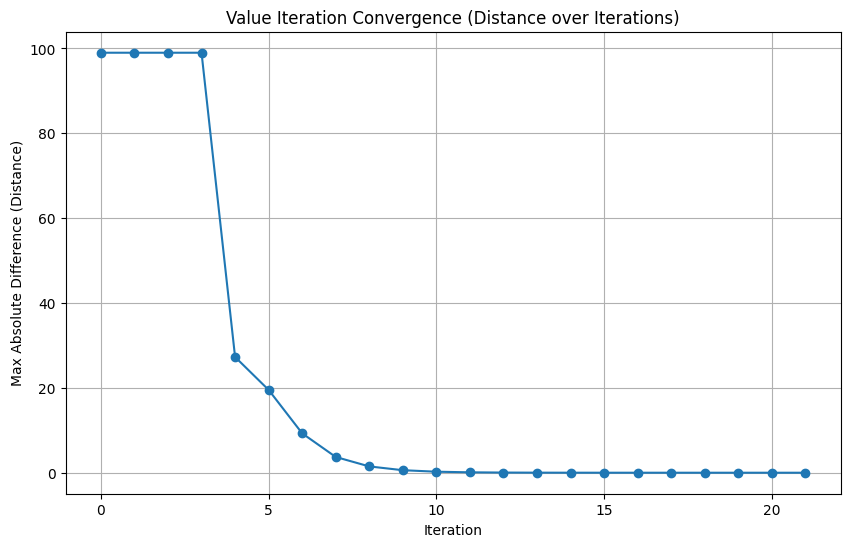

Optimal Values:
  State 1: -7.3333
  State 2: -6.3333
  State 3: -5.3333
  State 4: -4.3333
  State 5: -3.3333
  State 6: -4.0000
  State 7: -3.0000
  State 8: -2.0000
  State 9: -1.0000
  State 10: 0.0000

Optimal Policy:
  State 1: walk
  State 2: walk
  State 3: walk
  State 4: walk
  State 5: tram
  State 6: walk
  State 7: walk
  State 8: walk
  State 9: walk
  State 10: None


In [ ]:
import matplotlib.pyplot as plt

# Plot the distances from the ValueIterationResult
plt.figure(figsize=(10, 6))
plt.plot(result.distances, marker='o', linestyle='-')
plt.title('Value Iteration Convergence (Distance over Iterations)')
plt.xlabel('Iteration')
plt.ylabel('Max Absolute Difference (Distance)')
plt.grid(True)
plt.show()

print("Optimal Values:")
for state, value in result.values.items():
    print(f"  State {state}: {value:.4f}")

print("\nOptimal Policy:")
for state, action in result.pi.items():
    print(f"  State {state}: {action}")